# DS3002 Assignment 4

Complete implementation for Parts A to E.

In [12]:
import os, random, time, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score, adjusted_rand_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TEST_SIZE = 0.2
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
print("Seeds fixed: 42")


ImportError: Numba needs NumPy 2.1 or less. Got NumPy 2.4.

In [11]:
pip install "numpy<2.2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Preprocessing

In [ ]:
cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
heart_raw = pd.read_csv(Path('..')/'processed.cleveland.data', header=None, names=cols)
print("Raw shape:", heart_raw.shape)
display(heart_raw.head())
print(heart_raw.dtypes)

Raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


Dataset shape and schema are confirmed before cleaning.

In [ ]:
heart = heart_raw.replace('?', np.nan).copy()
nan_counts = heart.isna().sum()
print("Affected columns:")
print(nan_counts[nan_counts>0])
print("Rows with any NaN:", heart.isna().any(axis=1).sum())
for c in heart.columns:
    heart[c] = pd.to_numeric(heart[c], errors='coerce')
heart_clean = heart.dropna().reset_index(drop=True)
print("Retained rows:", len(heart_clean))
print("Clean shape:", heart_clean.shape)

Affected columns:
ca      4
thal    2
dtype: int64
Rows with any NaN: 6
Retained rows: 297
Clean shape: (297, 14)


Missing rows are removed after converting '?' to NaN.

In [ ]:
heart_clean['target'] = (heart_clean['target'] >= 1).astype(int)
print("Class distribution:")
print(heart_clean['target'].value_counts())
X_all = heart_clean.drop(columns=['target'])
y_all = heart_clean['target']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)
imbalance_ratio = y_train.value_counts(normalize=True).min()
apply_smote = imbalance_ratio < 0.40
print("Apply SMOTE only on train:", apply_smote)

Class distribution:
target
0    160
1    137
Name: count, dtype: int64
Apply SMOTE only on train: False


Target is binarized and split stratified with random_state=42.

In [ ]:
cat_cols = ['cp','restecg','slope','thal']
num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=False)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])
if apply_smote:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_model, y_train_model = sm.fit_resample(X_train_enc, y_train)
else:
    X_train_model, y_train_model = X_train_enc.copy(), y_train.copy()
print("Train shape:", X_train_model.shape, "Test shape:", X_test_enc.shape)

Train shape: (237, 22) Test shape: (60, 22)


One-hot encoding and scaling are train-fitted to avoid leakage.

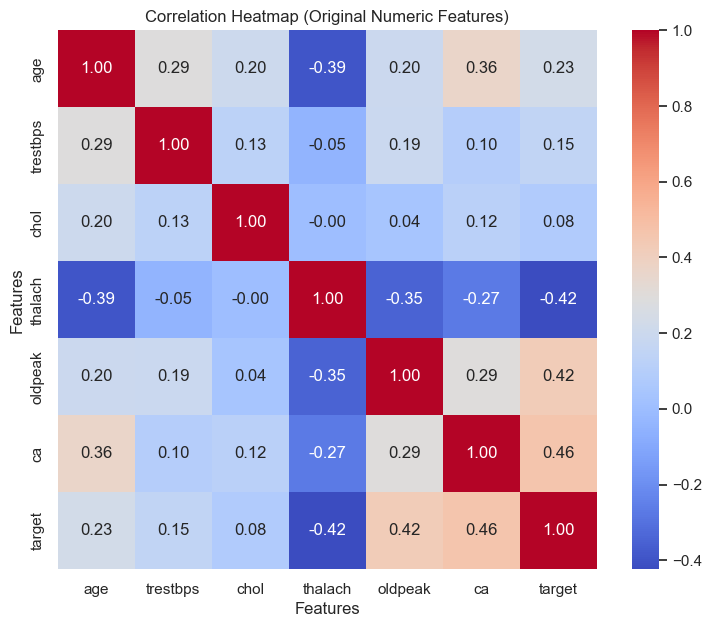

Top 3 correlated pairs:
target-ca: 0.463
oldpeak-target: 0.424
target-thalach: 0.424


In [ ]:
corr = heart_clean[['age','trestbps','chol','thalach','oldpeak','ca','target']].corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (Original Numeric Features)')
plt.xlabel('Features'); plt.ylabel('Features')
plt.show()
cpairs = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack().abs().sort_values(ascending=False)
seen = set(); top=[]
for (a,b),v in cpairs.items():
    k = tuple(sorted((a,b)))
    if k in seen: continue
    seen.add(k); top.append((a,b,v))
    if len(top)==3: break
print("Top 3 correlated pairs:")
for a,b,v in top: print(f"{a}-{b}: {v:.3f}")

Higher feature correlation implies weaker conditional independence assumptions for Naive Bayes.

## A1 — K-Means

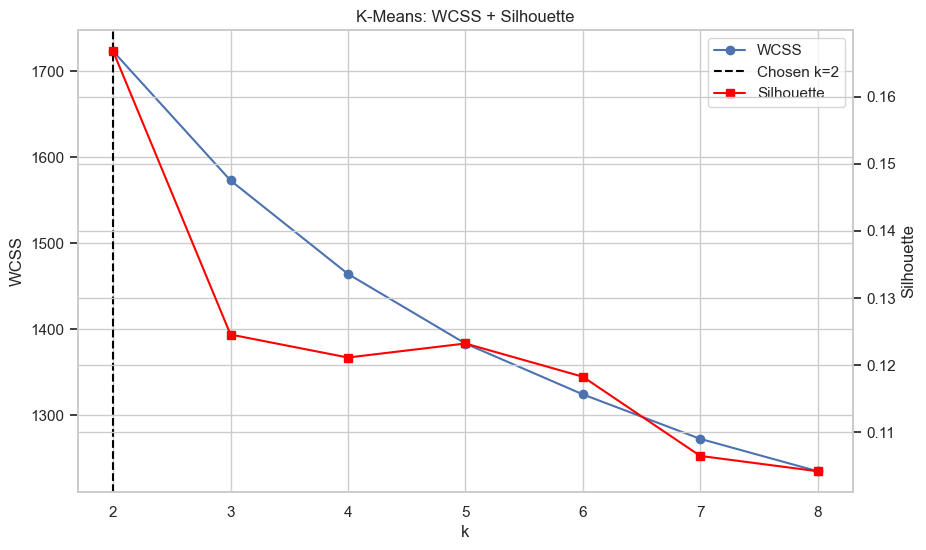

Chosen k: 2 ARI vs true labels: 0.2575


In [ ]:
X_cluster = X_train_enc.copy()
k_values = list(range(2,9))
wcss, sil = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_cluster)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_cluster, labels))
best_k = k_values[int(np.argmax(sil))]
fig, ax1 = plt.subplots(figsize=(10,6)); ax2 = ax1.twinx()
ax1.plot(k_values, wcss, marker='o', label='WCSS')
ax2.plot(k_values, sil, marker='s', color='red', label='Silhouette')
ax1.axvline(best_k, color='black', linestyle='--', label=f'Chosen k={best_k}')
ax1.set_title('K-Means: WCSS + Silhouette'); ax1.set_xlabel('k'); ax1.set_ylabel('WCSS'); ax2.set_ylabel('Silhouette')
lns=ax1.get_lines()+ax2.get_lines(); ax1.legend(lns,[l.get_label() for l in lns], loc='best')
plt.show()
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_cluster)
ari_true = adjusted_rand_score(y_train.values, kmeans_labels)
print("Chosen k:", best_k, "ARI vs true labels:", round(ari_true,4))

Selected k balances compactness and separation; ARI indicates partial alignment with diagnosis labels.

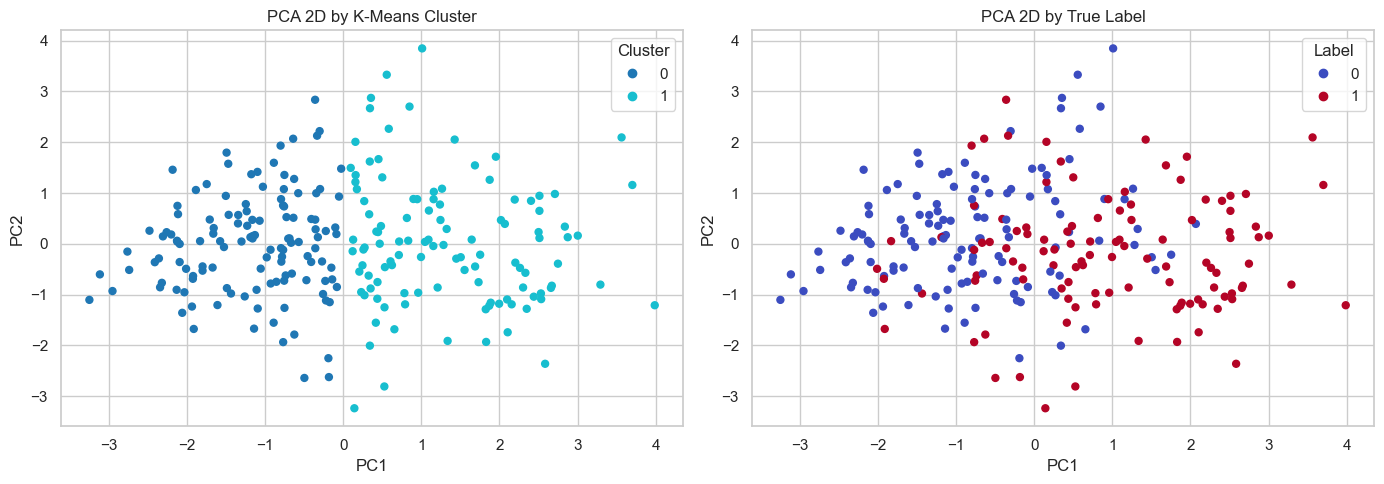

In [ ]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_cluster)
fig, axes = plt.subplots(1,2, figsize=(14,5))
s1=axes[0].scatter(pca2[:,0], pca2[:,1], c=kmeans_labels, cmap='tab10', s=25)
axes[0].set_title('PCA 2D by K-Means Cluster'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(*s1.legend_elements(), title='Cluster', loc='best')
s2=axes[1].scatter(pca2[:,0], pca2[:,1], c=y_train.values, cmap='coolwarm', s=25)
axes[1].set_title('PCA 2D by True Label'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(*s2.legend_elements(), title='Label', loc='best')
plt.tight_layout(); plt.show()

Cluster regions overlap with labels in some zones but remain mixed in others.

In [ ]:
cluster_df = X_train_raw.copy()
cluster_df['cluster'] = kmeans_labels
cluster_df['target'] = y_train.values
summary = cluster_df.groupby('cluster').agg(
    size=('target','size'),
    disease_pct=('target', lambda s: 100*s.mean()),
    mean_thalach=('thalach','mean'),
    mean_oldpeak=('oldpeak','mean'),
    mean_cp=('cp','mean')
).round(2)
display(summary)

,size,disease_pct,mean_thalach,mean_oldpeak,mean_cp
cluster,,,,,
0,126,22.22,162.86,0.51,2.94
1,111,72.97,135.07,1.69,3.47


Per-cluster clinical profiles indicate differing risk signatures in exercise and pain-related features.

## A2 — Hierarchical Clustering

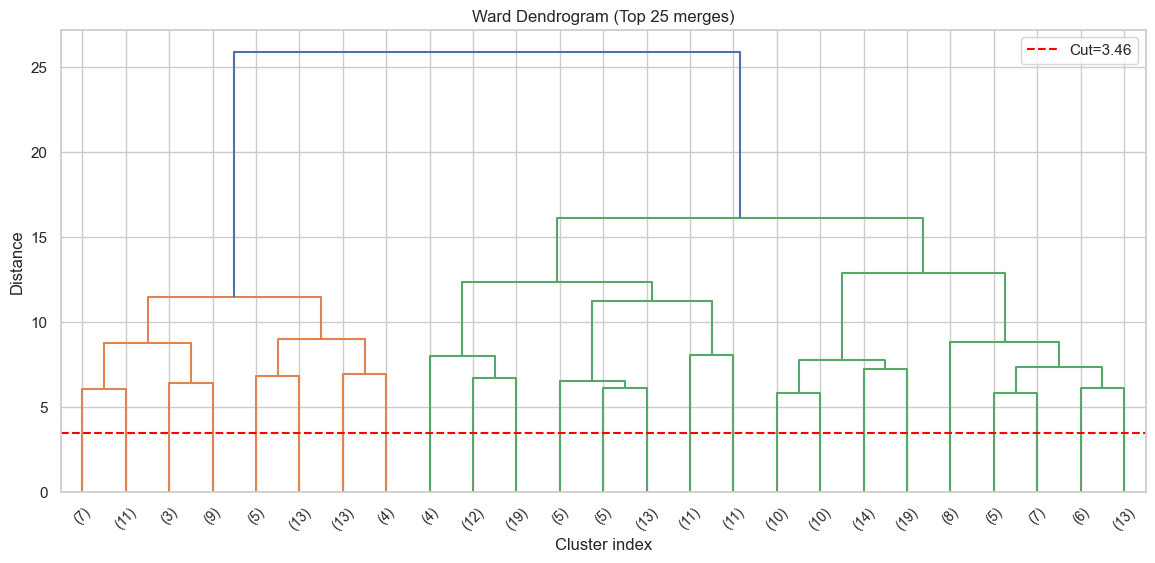

Resulting cluster count: 72


col_0,0,1
row_0,,
1,0.143,0.857
2,0.143,0.857
3,0.000,1.000
4,0.000,1.000
5,0.000,1.000
...,...,...
68,1.000,0.000
69,0.333,0.667
70,0.500,0.500


ARI (KMeans vs Hierarchical): 0.0228


In [ ]:
Z = linkage(X_cluster, method='ward')
plt.figure(figsize=(14,6))
dendrogram(Z, truncate_mode='lastp', p=25, leaf_rotation=45, leaf_font_size=10)
cut_height = np.percentile(Z[:,2], 70)
plt.axhline(cut_height, color='red', linestyle='--', label=f'Cut={cut_height:.2f}')
plt.title('Ward Dendrogram (Top 25 merges)')
plt.xlabel('Cluster index'); plt.ylabel('Distance'); plt.legend(); plt.show()
h_labels = fcluster(Z, t=cut_height, criterion='distance')
print("Resulting cluster count:", len(np.unique(h_labels)))
display(pd.crosstab(h_labels, y_train.values, normalize='index').round(3))
print("ARI (KMeans vs Hierarchical):", round(adjusted_rand_score(kmeans_labels, h_labels),4))

Hierarchical and K-Means solutions are related but differ at cluster boundaries and granularity.

## A3 — Dimensionality Reduction

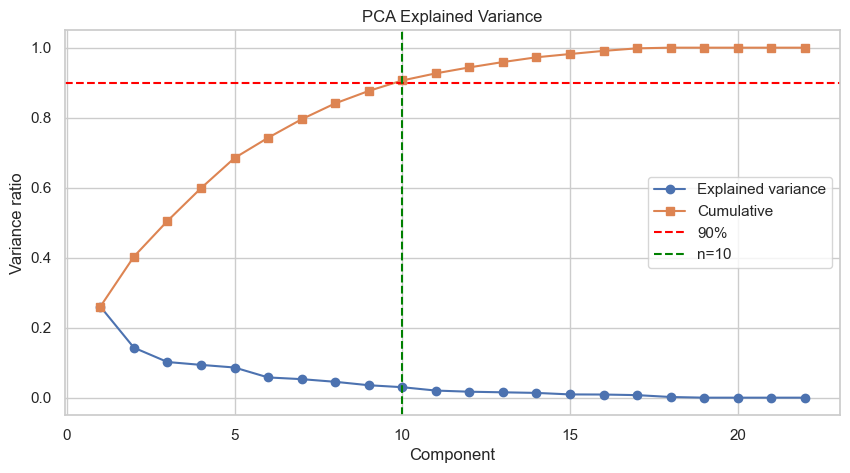

Components for 90% variance: 10


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_cluster)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.argmax(cum>=0.90)+1)
plt.figure(figsize=(10,5))
plt.plot(range(1,len(evr)+1), evr, marker='o', label='Explained variance')
plt.plot(range(1,len(cum)+1), cum, marker='s', label='Cumulative')
plt.axhline(0.9, color='red', linestyle='--', label='90%')
plt.axvline(n90, color='green', linestyle='--', label=f'n={n90}')
plt.title('PCA Explained Variance'); plt.xlabel('Component'); plt.ylabel('Variance ratio'); plt.legend(); plt.show()
print("Components for 90% variance:", n90)

PCA indicates how many components preserve most information while reducing dimensionality.

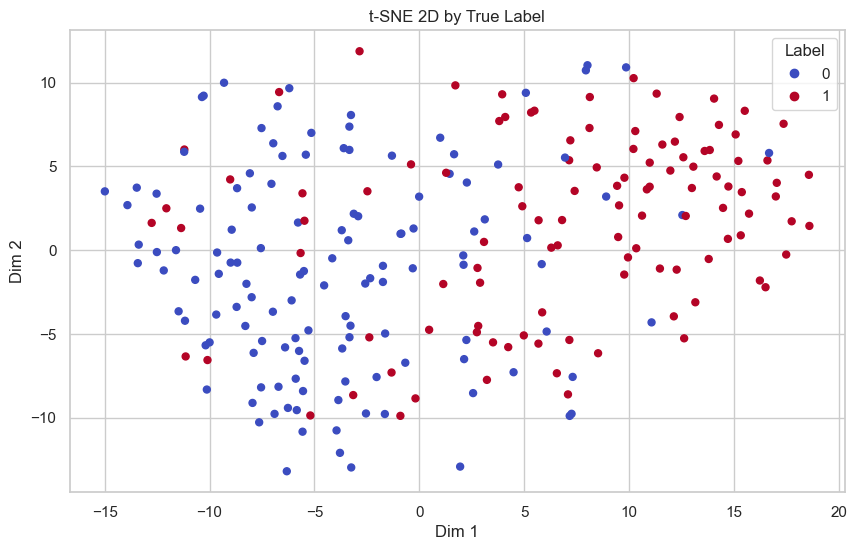

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_cluster)
plt.figure(figsize=(10,6))
s=plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train.values, cmap='coolwarm', s=25)
plt.title('t-SNE 2D by True Label'); plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
plt.legend(*s.legend_elements(), title='Label', loc='best')
plt.show()

t-SNE reveals non-linear local neighborhoods with partial disease-class separation.

## B1 — Random Forest

In [ ]:
def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'auc_roc': roc_auc_score(y_true, y_prob),
        'recall_disease': recall_score(y_true, y_pred, pos_label=1)
    }, y_pred

rf_grid = {'n_estimators':[50,100,200], 'max_depth':[None,5,10]}
rf_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
                         rf_grid, scoring='f1', cv=5, n_jobs=-1)
t0=time.time(); rf_search.fit(X_train_model, y_train_model); rf_train_time=time.time()-t0
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print("Best RF CV F1:", rf_search.best_score_)

Best RF params: {'max_depth': 5, 'n_estimators': 200}
Best RF CV F1: 0.7894725553658022


Random Forest is tuned using 5-fold F1 to emphasize positive-case retrieval.

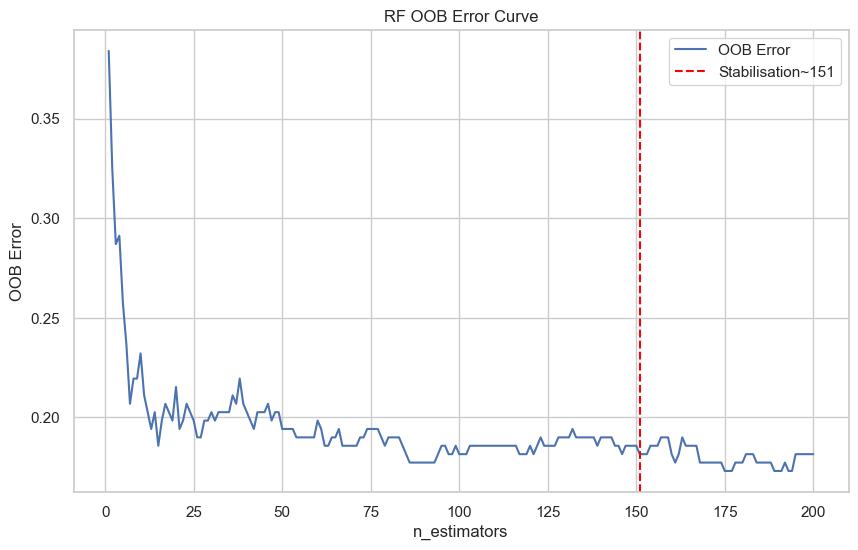

In [ ]:
errors=[]
rf_oob = RandomForestClassifier(n_estimators=1, warm_start=True, oob_score=True, bootstrap=True,
                                random_state=RANDOM_STATE, class_weight='balanced')
for n in range(1,201):
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train_model, y_train_model)
    errors.append(1-rf_oob.oob_score_)
stabil = int(np.argmin(np.abs(np.diff(errors[-50:])))+151) if len(errors)>=51 else 200
plt.figure(figsize=(10,6))
plt.plot(range(1,201), errors, label='OOB Error')
plt.axvline(stabil, color='red', linestyle='--', label=f'Stabilisation~{stabil}')
plt.title('RF OOB Error Curve'); plt.xlabel('n_estimators'); plt.ylabel('OOB Error'); plt.legend(); plt.show()

OOB error flattening indicates the stabilization point for tree count.

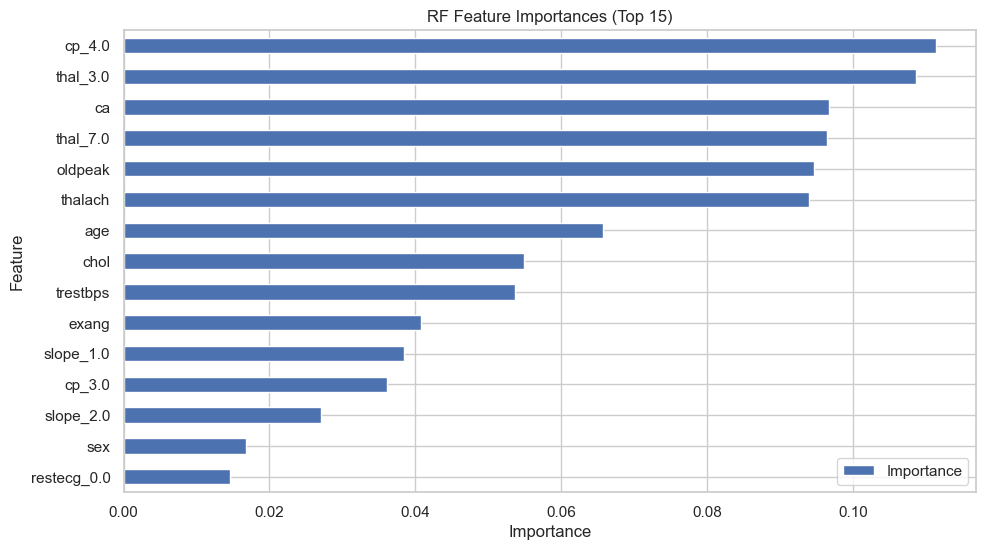

cp_4.0      0.111327
thal_3.0    0.108700
ca          0.096759
thal_7.0    0.096380
oldpeak     0.094654
dtype: float64


In [ ]:
rf_importances = pd.Series(best_rf.feature_importances_, index=X_train_model.columns).sort_values(ascending=False)
plt.figure(figsize=(11,6))
rf_importances.head(15).sort_values().plot(kind='barh')
plt.title('RF Feature Importances (Top 15)')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.legend(['Importance']); plt.show()
top5_rf = rf_importances.head(5)
print(top5_rf)

Top RF features reflect exercise response and cardiac function risk indicators.

RF Test Metrics:
accuracy 0.8333
macro_precision 0.8348
macro_recall 0.8304
macro_f1 0.8316
auc_roc 0.933
recall_disease 0.7857


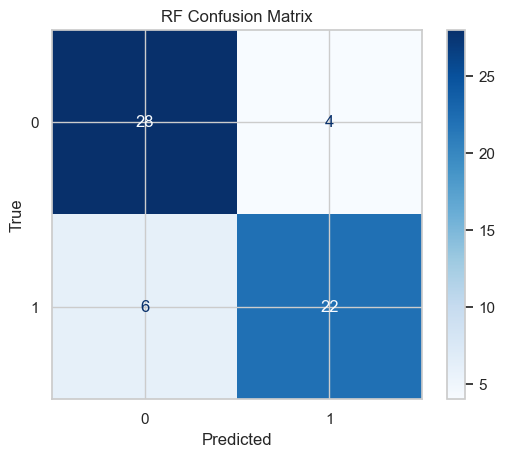

In [ ]:
rf_probs = best_rf.predict_proba(X_test_enc)[:,1]
rf_metrics, rf_pred = evaluate_binary(y_test, rf_probs)
print("RF Test Metrics:")
for k,v in rf_metrics.items():
    print(k, round(v,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred)).plot(cmap='Blues')
plt.title('RF Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

False negatives are critical in screening because missed disease cases delay care.

## B2 — Gradient Boosting (XGBoost)

In [ ]:
xgb_grid = {'learning_rate':[0.01,0.1,0.3], 'max_depth':[3,5,7]}
xgb_search = GridSearchCV(
    XGBClassifier(n_estimators=300, objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE),
    xgb_grid, scoring='f1', cv=5, n_jobs=-1
)
t0=time.time(); xgb_search.fit(X_train_model, y_train_model); xgb_train_time=time.time()-t0
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV F1:", xgb_search.best_score_)

Best XGB params: {'learning_rate': 0.1, 'max_depth': 7}
Best XGB CV F1: 0.7897445385326975


XGBoost hyperparameters are tuned for balanced precision-recall behavior.

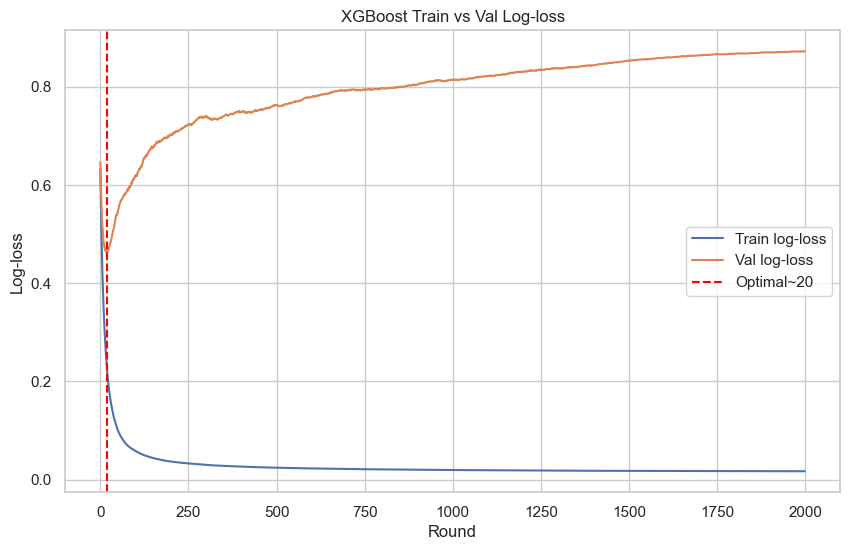

Best iteration: 19


In [ ]:
X_tr_boost, X_val_boost, y_tr_boost, y_val_boost = train_test_split(
    X_train_model, y_train_model, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_model
)
cfg = xgb_search.best_params_
tmp_xgb = XGBClassifier(n_estimators=2000, learning_rate=cfg['learning_rate'], max_depth=cfg['max_depth'],
                        objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE)
tmp_xgb.fit(X_tr_boost, y_tr_boost, eval_set=[(X_tr_boost,y_tr_boost),(X_val_boost,y_val_boost)], verbose=False)
res = tmp_xgb.evals_result()
tr_loss = res['validation_0']['logloss']; va_loss = res['validation_1']['logloss']
opt_round = int(np.argmin(va_loss)+1)
plt.figure(figsize=(10,6))
plt.plot(tr_loss, label='Train log-loss'); plt.plot(va_loss, label='Val log-loss')
plt.axvline(opt_round, color='red', linestyle='--', label=f'Optimal~{opt_round}')
plt.title('XGBoost Train vs Val Log-loss'); plt.xlabel('Round'); plt.ylabel('Log-loss'); plt.legend(); plt.show()

final_xgb = XGBClassifier(n_estimators=2000, learning_rate=cfg['learning_rate'], max_depth=cfg['max_depth'],
                          objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE,
                          early_stopping_rounds=50)
final_xgb.fit(X_tr_boost, y_tr_boost, eval_set=[(X_val_boost,y_val_boost)], verbose=False)
print("Best iteration:", final_xgb.best_iteration)

Early stopping limits overfitting by selecting the best validation round.

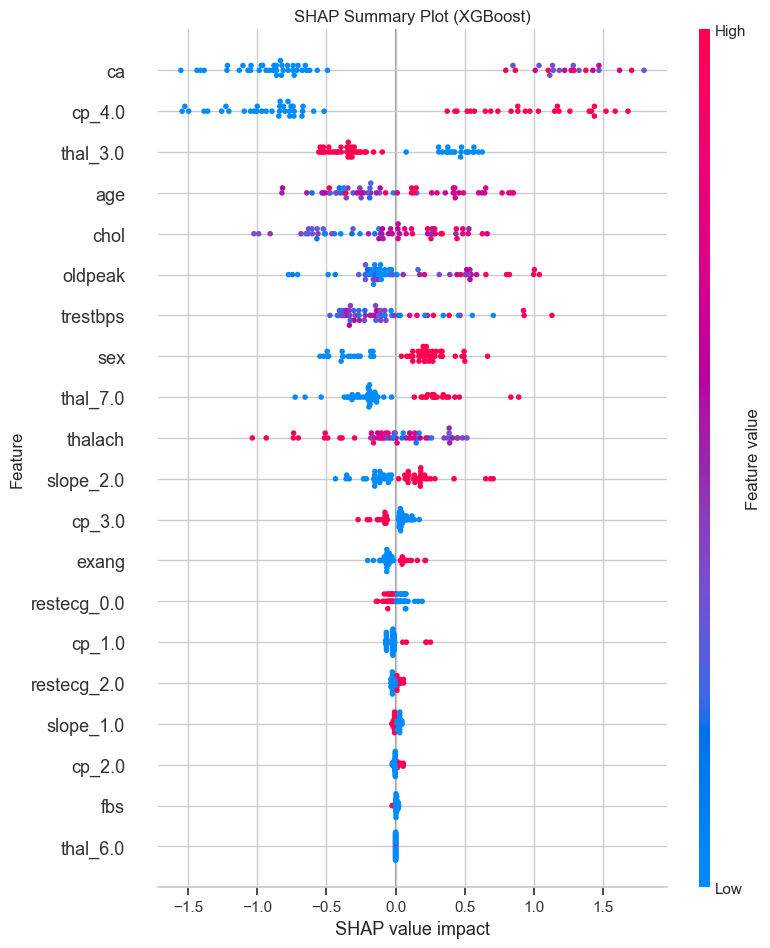

In [ ]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Ensure numeric matrix
X_test_shap = X_test_enc.astype(np.float32)

# XGBoost-native SHAP values (last column is bias term)
dm_test = xgb.DMatrix(X_test_shap, feature_names=X_test_shap.columns.tolist())
contrib = final_xgb.get_booster().predict(dm_test, pred_contribs=True)

# Remove bias column
shap_values = contrib[:, :-1]

# Summary plot
shap.summary_plot(shap_values, X_test_shap, show=False)
plt.title("SHAP Summary Plot (XGBoost)")
plt.xlabel("SHAP value impact")
plt.ylabel("Feature")
plt.show()

SHAP explains contribution magnitude and direction per feature.

XGB Test Metrics:
accuracy 0.7833
macro_precision 0.8004
macro_recall 0.7746
macro_f1 0.7758
auc_roc 0.9068
recall_disease 0.6429


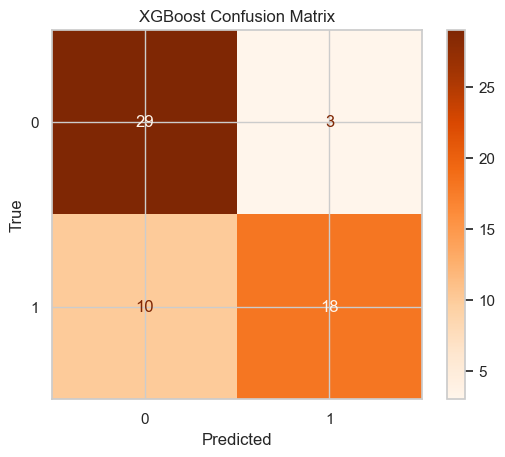

In [ ]:
xgb_probs = final_xgb.predict_proba(X_test_enc)[:,1]
xgb_metrics, xgb_pred = evaluate_binary(y_test, xgb_probs)
print("XGB Test Metrics:")
for k,v in xgb_metrics.items():
    print(k, round(v,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_pred)).plot(cmap='Oranges')
plt.title('XGBoost Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

Boosting often improves ranking performance through staged error correction.

## B3 — Comparison

,Model,Accuracy,Macro F1,AUC-ROC,Recall(Disease),Train Time
0,Best previous classifier (LogisticRegression),0.8500,0.8479,0.9509,0.7857,0.0180
1,Random Forest,0.8333,0.8316,0.9330,0.7857,3.1607
2,XGBoost,0.7833,0.7758,0.9068,0.6429,1.8267


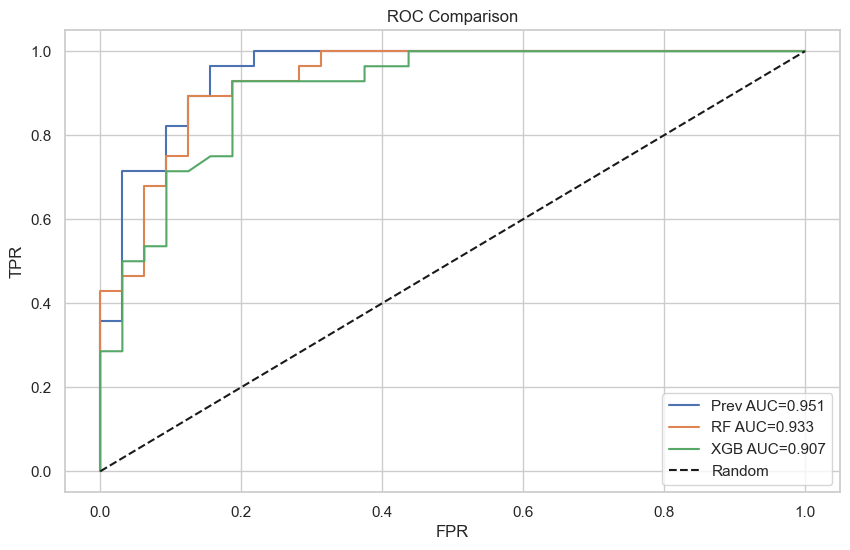

In [ ]:
t0=time.time()
prev_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
prev_clf.fit(X_train_model, y_train_model)
prev_time = time.time()-t0
prev_probs = prev_clf.predict_proba(X_test_enc)[:,1]
prev_metrics, _ = evaluate_binary(y_test, prev_probs)

comparison = pd.DataFrame([
    ['Best previous classifier (LogisticRegression)', prev_metrics['accuracy'], prev_metrics['macro_f1'], prev_metrics['auc_roc'], prev_metrics['recall_disease'], prev_time],
    ['Random Forest', rf_metrics['accuracy'], rf_metrics['macro_f1'], rf_metrics['auc_roc'], rf_metrics['recall_disease'], rf_train_time],
    ['XGBoost', xgb_metrics['accuracy'], xgb_metrics['macro_f1'], xgb_metrics['auc_roc'], xgb_metrics['recall_disease'], xgb_train_time],
], columns=['Model','Accuracy','Macro F1','AUC-ROC','Recall(Disease)','Train Time'])
display(comparison.round(4))

fpr_p, tpr_p, _ = roc_curve(y_test, prev_probs)
fpr_r, tpr_r, _ = roc_curve(y_test, rf_probs)
fpr_x, tpr_x, _ = roc_curve(y_test, xgb_probs)
plt.figure(figsize=(10,6))
plt.plot(fpr_p, tpr_p, label=f'Prev AUC={prev_metrics["auc_roc"]:.3f}')
plt.plot(fpr_r, tpr_r, label=f'RF AUC={rf_metrics["auc_roc"]:.3f}')
plt.plot(fpr_x, tpr_x, label=f'XGB AUC={xgb_metrics["auc_roc"]:.3f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.title('ROC Comparison'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.show()

Deployment should prioritize disease recall over accuracy because missing true disease cases has higher clinical cost than extra follow-up tests.

## C1 — SLP

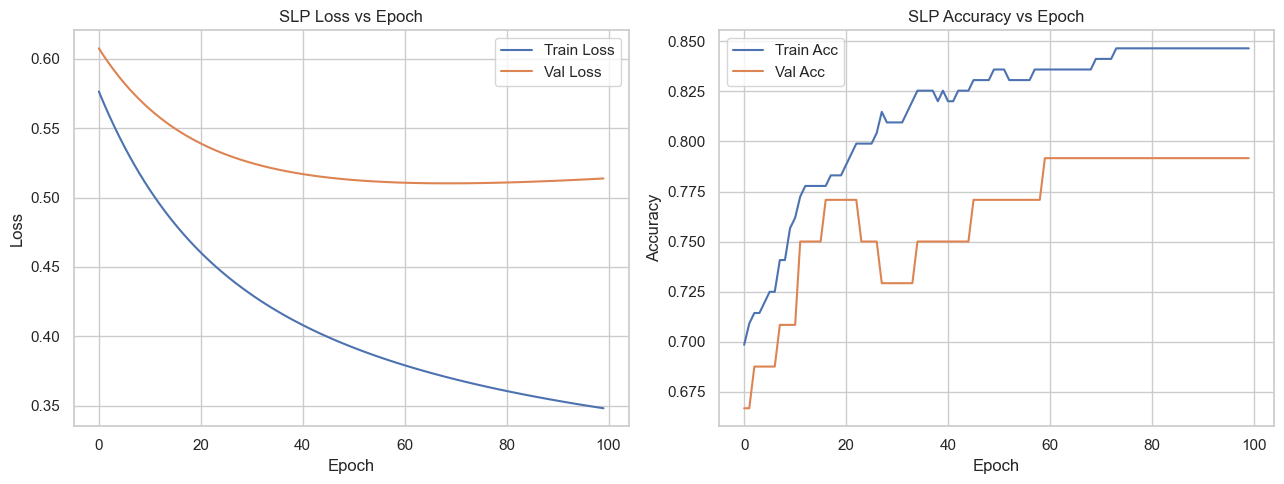

accuracy 0.8167
macro_precision 0.82
macro_recall 0.8125
macro_f1 0.8141
auc_roc 0.942
recall_disease 0.75


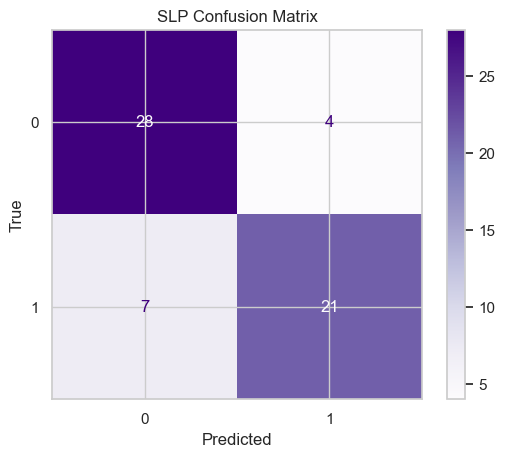

Top 3 SLP abs weights:
thal_3.0     0.755509
slope_1.0    0.737908
cp_4.0       0.704240
dtype: float32
Top 3 RF importances:
cp_4.0      0.111327
thal_3.0    0.108700
ca          0.096759
dtype: float64


In [ ]:
X_train_nn = X_train_model.values.astype('float32')
X_test_nn = X_test_enc.values.astype('float32')
y_train_nn = np.array(y_train_model).astype('float32')
y_test_nn = y_test.values.astype('float32')
slp = models.Sequential([layers.Input(shape=(X_train_nn.shape[1],)), layers.Dense(1, activation='sigmoid')])
slp.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
h_slp = slp.fit(X_train_nn, y_train_nn, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].plot(h_slp.history['loss'], label='Train Loss'); axes[0].plot(h_slp.history['val_loss'], label='Val Loss')
axes[0].set_title('SLP Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(h_slp.history['accuracy'], label='Train Acc'); axes[1].plot(h_slp.history['val_accuracy'], label='Val Acc')
axes[1].set_title('SLP Accuracy vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()
slp_probs = slp.predict(X_test_nn, verbose=0).ravel()
slp_metrics, slp_pred = evaluate_binary(y_test_nn, slp_probs)
for k,v in slp_metrics.items(): print(k, round(v,4))
ConfusionMatrixDisplay(confusion_matrix(y_test_nn, slp_pred)).plot(cmap='Purples')
plt.title('SLP Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
slp_imp = pd.Series(np.abs(slp.layers[0].get_weights()[0].ravel()), index=X_train_model.columns).sort_values(ascending=False)
print("Top 3 SLP abs weights:"); print(slp_imp.head(3))
print("Top 3 RF importances:"); print(top5_rf.head(3))

SLP is limited by linearity and may not capture complex interactions as effectively as ensembles.

## C2 — MLP

In [ ]:
X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_train_nn, y_train_nn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_nn
)
def build_mlp(arch='small', activation='relu', dropout=0.3, l2_val=1e-4):
    m = models.Sequential(); m.add(layers.Input(shape=(X_train_nn.shape[1],)))
    reg = regularizers.l2(l2_val) if l2_val else None
    if arch=='small':
        m.add(layers.Dense(32, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
    elif arch=='medium':
        m.add(layers.Dense(64, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
        m.add(layers.Dense(32, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
    else:
        m.add(layers.Dense(128, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
        m.add(layers.Dense(64, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
        m.add(layers.Dense(32, activation=activation, kernel_regularizer=reg))
        if dropout: m.add(layers.Dropout(dropout))
    m.add(layers.Dense(1, activation='sigmoid'))
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

arch_map = {'Small (32)': 'small', 'Medium (64→32)': 'medium', 'Large (128→64→32)': 'large'}
rows=[]; histories={}
for name,a in arch_map.items():
    m=build_mlp(arch=a)
    cb=callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    t0=time.time(); h=m.fit(X_tr_nn, y_tr_nn, validation_data=(X_val_nn,y_val_nn), epochs=150, batch_size=32, callbacks=[cb], verbose=0); dt=time.time()-t0
    vp=(m.predict(X_val_nn, verbose=0).ravel()>=0.5).astype(int)
    rows.append([name, f1_score(y_val_nn, vp), dt, len(h.history['loss'])]); histories[name]=(m,h)
arch_df = pd.DataFrame(rows, columns=['Architecture','Val F1','Train Time','Epochs'])
display(arch_df.sort_values('Val F1', ascending=False).round(4))
best_name = arch_df.sort_values('Val F1', ascending=False).iloc[0]['Architecture']
best_mlp, best_hist = histories[best_name]
print("Best MLP:", best_name)

,Architecture,Val F1,Train Time,Epochs
1,Medium (64→32),0.8511,5.9860,35
2,Large (128→64→32),0.8444,5.9313,27
0,Small (32),0.8261,8.3939,58


Best MLP: Medium (64→32)


Best MLP uses ReLU + Adam with Dropout and L2, plus EarlyStopping(patience=10).

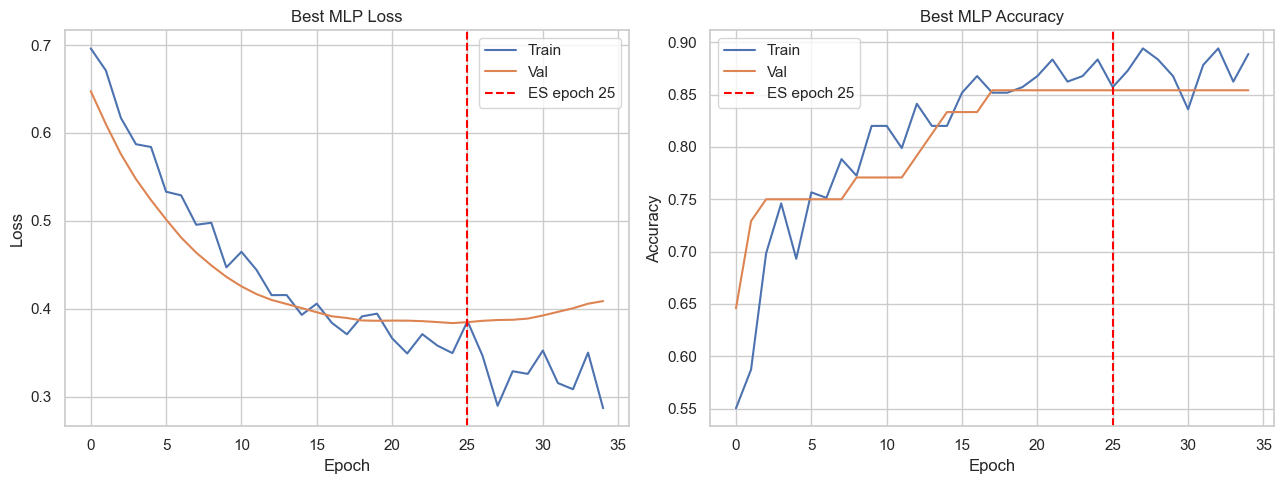

5-fold CV Accuracy: 0.8184 ± 0.0654
5-fold CV F1: 0.7932 ± 0.0797
accuracy 0.8833
macro_precision 0.8838
macro_recall 0.8817
macro_f1 0.8825
auc_roc 0.952
recall_disease 0.8571


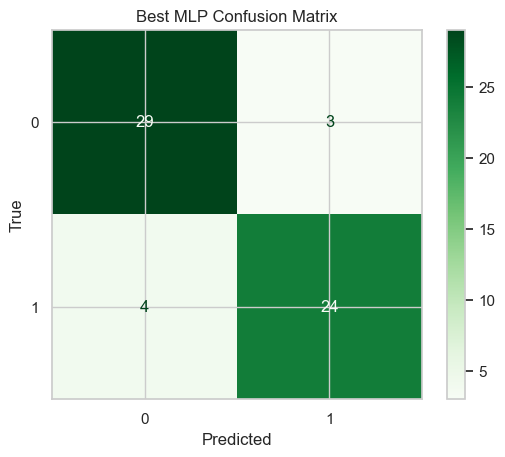

In [ ]:
best_epoch = int(np.argmin(best_hist.history['val_loss'])+1)
fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].plot(best_hist.history['loss'], label='Train'); axes[0].plot(best_hist.history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'ES epoch {best_epoch}')
axes[0].set_title('Best MLP Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(best_hist.history['accuracy'], label='Train'); axes[1].plot(best_hist.history['val_accuracy'], label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'ES epoch {best_epoch}')
axes[1].set_title('Best MLP Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc, cv_f1 = [], []
for tr, va in skf.split(X_train_nn, y_train_nn):
    m = build_mlp(arch=arch_map[best_name], activation='relu', dropout=0.3, l2_val=1e-4)
    cb=callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(X_train_nn[tr], y_train_nn[tr], validation_data=(X_train_nn[va], y_train_nn[va]), epochs=100, batch_size=32, callbacks=[cb], verbose=0)
    pr=(m.predict(X_train_nn[va], verbose=0).ravel()>=0.5).astype(int)
    cv_acc.append(accuracy_score(y_train_nn[va], pr)); cv_f1.append(f1_score(y_train_nn[va], pr))
print(f"5-fold CV Accuracy: {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")
print(f"5-fold CV F1: {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")
mlp_probs = best_mlp.predict(X_test_nn, verbose=0).ravel()
mlp_metrics, mlp_pred = evaluate_binary(y_test_nn, mlp_probs)
for k,v in mlp_metrics.items(): print(k, round(v,4))
ConfusionMatrixDisplay(confusion_matrix(y_test_nn, mlp_pred)).plot(cmap='Greens')
plt.title('Best MLP Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

MLP can be competitive but ensemble trees are often more stable on small tabular clinical datasets.

## C3 — Ablation Study

In [ ]:
def train_variant(activation='relu', dropout=0.3, early_stop=True, epochs=150):
    m = build_mlp(arch=arch_map[best_name], activation=activation, dropout=dropout, l2_val=1e-4)
    cbs = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)] if early_stop else []
    h = m.fit(X_tr_nn, y_tr_nn, validation_data=(X_val_nn, y_val_nn), epochs=epochs, batch_size=32, callbacks=cbs, verbose=0)
    p = (m.predict(X_test_nn, verbose=0).ravel()>=0.5).astype(int)
    return f1_score(y_test_nn, p), float(np.min(h.history['val_loss']))

rows=[]
f1b,vlb = train_variant('relu',0.3,True,150); rows.append(['Best MLP', f1b, f'best val_loss={vlb:.4f}'])
f1a,vla = train_variant('relu',0.0,True,150); rows.append(['A) no Dropout', f1a, f'best val_loss={vla:.4f}'])
f1s,vls = train_variant('sigmoid',0.3,True,150); rows.append(['B) Sigmoid activations', f1s, f'best val_loss={vls:.4f}'])
f1f,vlf = train_variant('relu',0.3,False,150); rows.append(['C) fixed 150 epochs (no EarlyStopping)', f1f, f'best val_loss={vlf:.4f}'])
ablation = pd.DataFrame(rows, columns=['Model Variant','Test F1','Val-loss note'])
display(ablation.round(4))

,Model Variant,Test F1,Val-loss note
0,Best MLP,0.8519,best val_loss=0.4050
1,A) no Dropout,0.8077,best val_loss=0.3707
2,B) Sigmoid activations,0.8519,best val_loss=0.3865
3,C) fixed 150 epochs (no EarlyStopping),0.8421,best val_loss=0.4084


Regularization and stopping policy usually have the largest impact on tabular neural-network generalization.

## D1 — Baseline

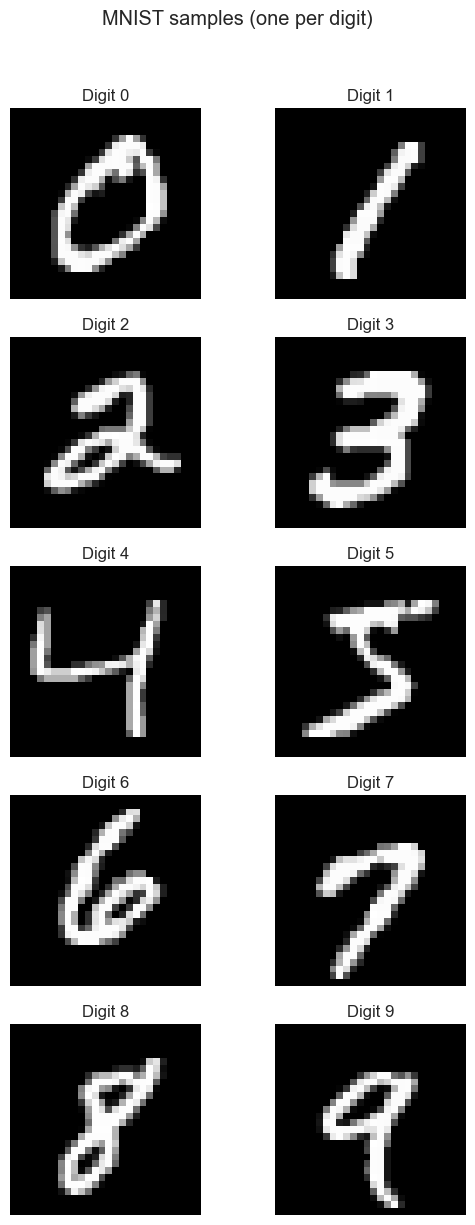

MLP baseline test accuracy: 0.9015


In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()
x_train = x_train_full[:12000].astype('float32')/255.0
x_test = x_test_full[:2000].astype('float32')/255.0
y_train_img = y_train_full[:12000]; y_test_img = y_test_full[:2000]
x_train_cnn = x_train[..., np.newaxis]; x_test_cnn = x_test[..., np.newaxis]
y_train_cat = to_categorical(y_train_img,10); y_test_cat = to_categorical(y_test_img,10)

fig, axes = plt.subplots(5,2, figsize=(6,12))
for d in range(10):
    idx = np.where(y_train_img==d)[0][0]
    ax = axes[d//2, d%2]
    ax.imshow(x_train[idx], cmap='gray'); ax.set_title(f'Digit {d}'); ax.axis('off')
plt.suptitle('MNIST samples (one per digit)', y=1.02); plt.tight_layout(); plt.show()

mlp_img = models.Sequential([layers.Input(shape=(28,28,1)), layers.Flatten(), layers.Dense(64, activation='relu'), layers.Dense(10, activation='softmax')])
mlp_img.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_img.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=128, validation_split=0.1, verbose=0)
_, mlp_test_acc = mlp_img.evaluate(x_test_cnn, y_test_cat, verbose=0)
print("MLP baseline test accuracy:", round(float(mlp_test_acc),4))

The fully connected baseline provides a non-convolutional reference.

## D2 — Lightweight CNN

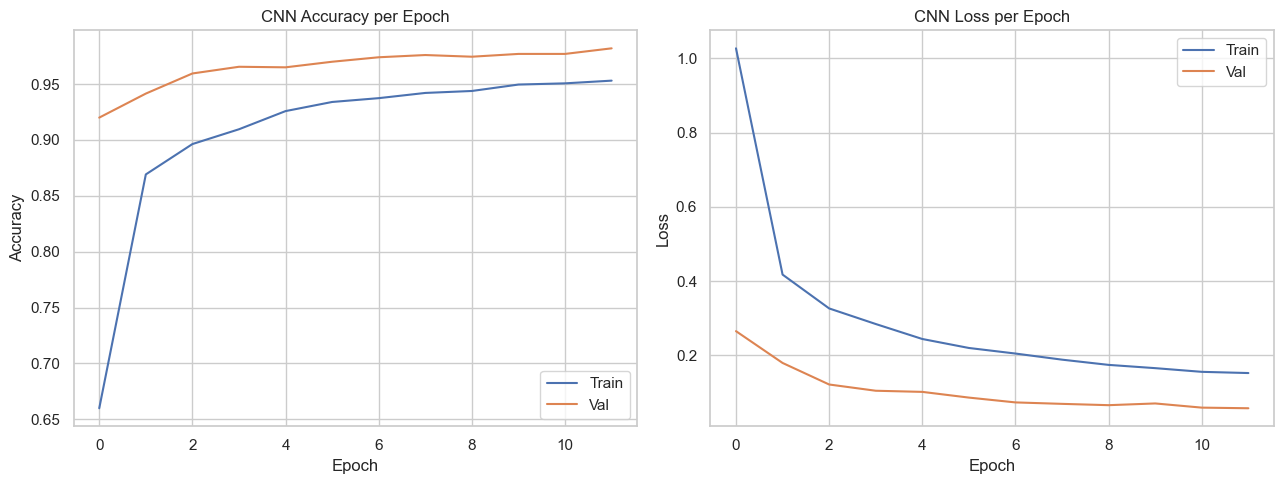

CNN test accuracy: 0.982
CNN macro F1: 0.9816


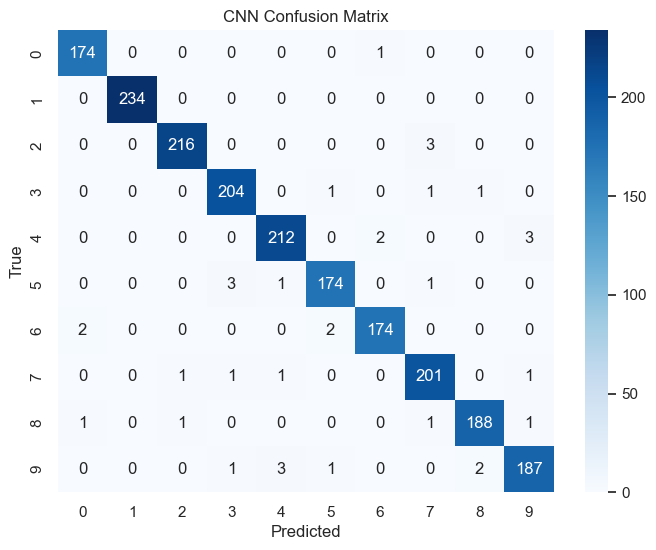

Two most-confused digit pairs: [(2, 7, np.int64(3)), (4, 9, np.int64(3))]
Epoch CNN surpasses MLP baseline: 1


In [ ]:
cnn = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
aug = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1)
aug.fit(x_train_cnn)
h_cnn = cnn.fit(aug.flow(x_train_cnn, y_train_cat, batch_size=64, seed=RANDOM_STATE), epochs=12, validation_data=(x_test_cnn, y_test_cat), verbose=0)

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].plot(h_cnn.history['accuracy'], label='Train'); axes[0].plot(h_cnn.history['val_accuracy'], label='Val')
axes[0].set_title('CNN Accuracy per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(h_cnn.history['loss'], label='Train'); axes[1].plot(h_cnn.history['val_loss'], label='Val')
axes[1].set_title('CNN Loss per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

cnn_probs = cnn.predict(x_test_cnn, verbose=0)
cnn_pred = np.argmax(cnn_probs, axis=1)
cnn_acc = accuracy_score(y_test_img, cnn_pred)
cnn_f1 = f1_score(y_test_img, cnn_pred, average='macro')
print("CNN test accuracy:", round(cnn_acc,4))
print("CNN macro F1:", round(cnn_f1,4))
cm = confusion_matrix(y_test_img, cnn_pred)
plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
cm2 = cm.copy(); np.fill_diagonal(cm2, 0)
pairs=[]
for i in range(10):
    for j in range(10):
        if i!=j and cm2[i,j]>0: pairs.append((i,j,cm2[i,j]))
pairs = sorted(pairs, key=lambda x:x[2], reverse=True)[:2]
print("Two most-confused digit pairs:", pairs)
surpass = next((i+1 for i,v in enumerate(h_cnn.history['val_accuracy']) if v>mlp_test_acc), None)
print("Epoch CNN surpasses MLP baseline:", surpass)

Confusions mostly occur for visually similar digit shapes; CNN generally surpasses baseline quickly.

## D3 — Visualising Filters

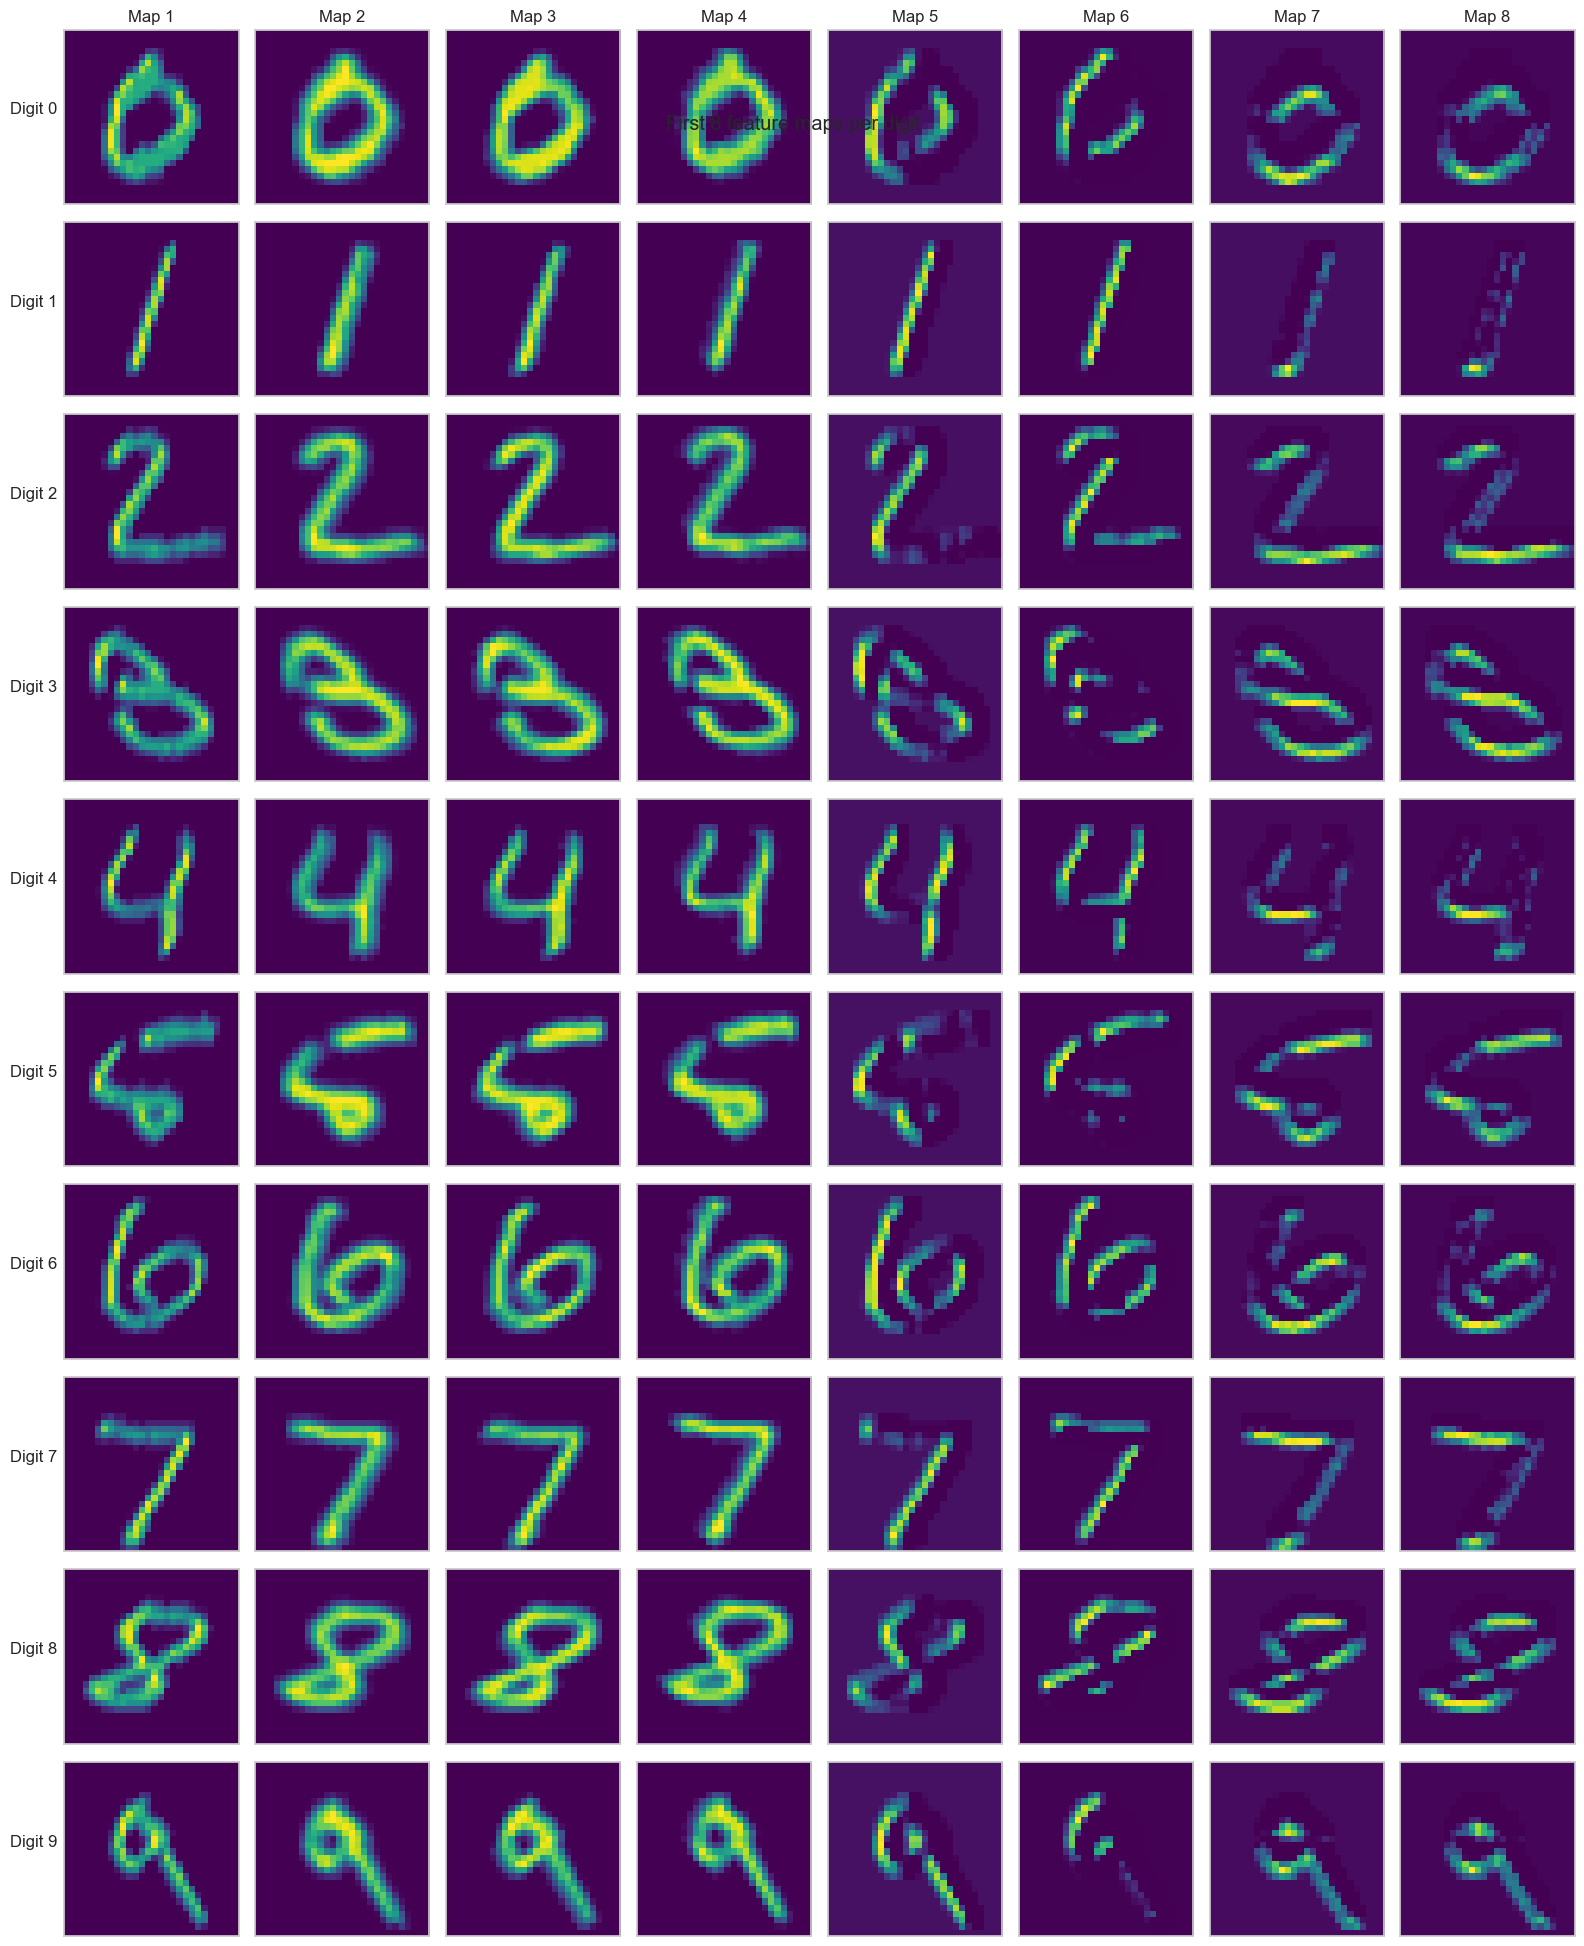

In [ ]:
# Ensure model is built/called in this session
_ = cnn.predict(x_test_cnn[:1], verbose=0)

# Use .inputs[0] (more robust than cnn.input in Keras 3)
feat_model = tf.keras.Model(inputs=cnn.inputs[0], outputs=cnn.layers[0].output)

# Visualize first 8 feature maps for one sample per digit
fig, axes = plt.subplots(10, 8, figsize=(16, 20))
for d in range(10):
    idx = np.where(y_test_img == d)[0][0]
    fmap = feat_model.predict(x_test_cnn[idx:idx+1], verbose=0)[0]
    for j in range(8):
        ax = axes[d, j]
        ax.imshow(fmap[:, :, j], cmap='viridis')
        if j == 0:
            ax.set_ylabel(f'Digit {d}', rotation=0, labelpad=22)
        if d == 0:
            ax.set_title(f'Map {j+1}')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('First 8 feature maps per digit', y=0.92)
plt.tight_layout()
plt.show()

Visualizing filters and activations improves transparency and trust compared to opaque fully connected internals.

## E — Local Streamlit Dashboard

In [ ]:
model_scores = {'RandomForest': rf_metrics['macro_f1'], 'XGBoost': xgb_metrics['macro_f1'], 'MLP': mlp_metrics['macro_f1']}
best_model_name = max(model_scores, key=model_scores.get)
best_model_obj = {'RandomForest': best_rf, 'XGBoost': final_xgb, 'MLP': best_mlp}[best_model_name]
bundle = {
    'model_name': best_model_name,
    'model': best_model_obj,
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'feature_columns': list(X_train_enc.columns),
    'scaler': scaler,
    'reference_row': X_test_raw.iloc[0].to_dict()
}
joblib.dump(bundle, Path('model.pkl'))
print("Saved model.pkl with best model:", best_model_name)

Saved model.pkl with best model: MLP
